In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
df = pd.read_csv("../nyc311.csv")

print(df.head())

print(df.columns)

   Unique Key      Created Date    Closed Date Agency  \
0    32310363  12/31/2015 23:59  1/1/2016 0:55   NYPD   
1    32309934  12/31/2015 23:59  1/1/2016 1:26   NYPD   
2    32309159  12/31/2015 23:59  1/1/2016 4:51   NYPD   
3    32305098  12/31/2015 23:57  1/1/2016 7:43   NYPD   
4    32306529  12/31/2015 23:56  1/1/2016 3:24   NYPD   

                       Agency Name           Complaint Type  \
0  New York City Police Department  Noise - Street/Sidewalk   
1  New York City Police Department         Blocked Driveway   
2  New York City Police Department         Blocked Driveway   
3  New York City Police Department          Illegal Parking   
4  New York City Police Department          Illegal Parking   

                     Descriptor    Location Type  Incident Zip  \
0              Loud Music/Party  Street/Sidewalk       10034.0   
1                     No Access  Street/Sidewalk       11105.0   
2                     No Access  Street/Sidewalk       10458.0   
3  Commercial 

In [3]:
df = df[['Complaint Type', 'Descriptor']]

df = df.dropna()

df['text'] = df['Complaint Type'] + " " + df['Descriptor']

print(df.head())

            Complaint Type                    Descriptor  \
0  Noise - Street/Sidewalk              Loud Music/Party   
1         Blocked Driveway                     No Access   
2         Blocked Driveway                     No Access   
3          Illegal Parking  Commercial Overnight Parking   
4          Illegal Parking              Blocked Sidewalk   

                                           text  
0      Noise - Street/Sidewalk Loud Music/Party  
1                    Blocked Driveway No Access  
2                    Blocked Driveway No Access  
3  Illegal Parking Commercial Overnight Parking  
4              Illegal Parking Blocked Sidewalk  


In [4]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Apply cleaning to dataset
df["clean_text"] = df["text"].apply(clean_text)

# Show result
print(df[["text", "clean_text"]].head())

NameError: name 'stop_words' is not defined

In [ ]:
X = df['clean_text']

y = df['Complaint Type']

In [ ]:
department_mapping = {
    "noise": "Police",
    "blocked driveway": "Transport",
    "street condition": "Road Maintenance",
    "water leakage": "Water Department",
    "sewer": "Water Department",
    "garbage": "Sanitation",
    "illegal parking": "Traffic",
    "street light": "Electricity"
}

In [ ]:
df["department"] = df["Complaint Type"].str.lower().map(department_mapping)
df = df.dropna()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 27608
Testing samples: 6902


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(27608, 81)


In [ ]:
model = LogisticRegression(max_iter=200)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

['Noise - Street/Sidewalk' 'Illegal Parking' 'Illegal Parking'
 'Illegal Parking' 'Noise - Commercial' 'Noise - Vehicle'
 'Illegal Parking' 'Blocked Driveway' 'Illegal Parking'
 'Noise - Commercial']
Model Accuracy: 1.0


In [ ]:
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

                          precision    recall  f1-score   support

            Animal Abuse       1.00      1.00      1.00       191
        Blocked Driveway       1.00      1.00      1.00      2232
        Derelict Vehicle       1.00      1.00      1.00       447
        Disorderly Youth       1.00      1.00      1.00         4
                Drinking       1.00      1.00      1.00        19
                Graffiti       1.00      1.00      1.00         3
         Illegal Parking       1.00      1.00      1.00      2023
      Noise - Commercial       1.00      1.00      1.00       887
Noise - House of Worship       1.00      1.00      1.00        10
            Noise - Park       1.00      1.00      1.00        26
 Noise - Street/Sidewalk       1.00      1.00      1.00       560
         Noise - Vehicle       1.00      1.00      1.00       267
   Posting Advertisement       1.00      1.00      1.00        36
                 Traffic       1.00      1.00      1.00       114
         

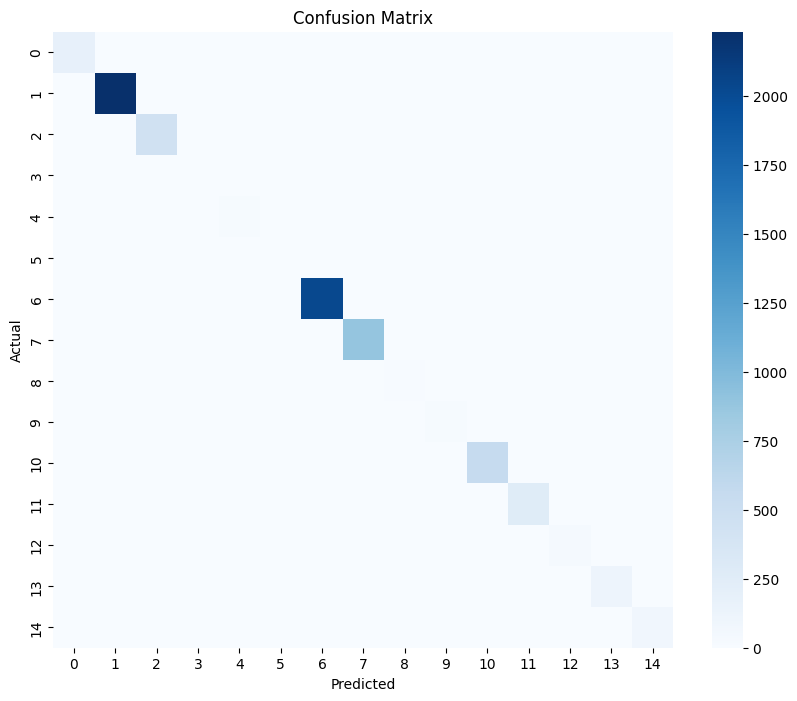

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(cm, cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train_tfidf,
    y_train,
    cv=5
)

print("Cross Validation Scores:", scores)

print("Average CV Score:", scores.mean())

Cross Validation Scores: [1. 1. 1. 1. 1.]
Average CV Score: 1.0


In [ ]:
import joblib

joblib.dump(model, "../models/complaint_classifier.pkl")

joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("Week 2 model saved successfully")

Week 2 model saved successfully
